# Step 5 — Basket analysis

Which products sell together. Association rules (FP-Growth) over all valid invoices, anonymous baskets included, since the unit here is the invoice, not the customer. Ranked by **lift**, which ignores how popular a product is on its own.

In [1]:
# Setup: run from the project root so the data directory and results/
# resolve exactly as they do in main.py, and the step modules import.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import pandas as pd
from IPython.display import Image, display

DATA_DIR = "kaggle_customer_intelligence"


In [2]:
# Small loaders for the artefacts the earlier steps saved.
def load_sales():
    p = f"{DATA_DIR}/clean_sales.parquet"
    try:
        return pd.read_parquet(p)
    except Exception:
        df = pd.read_csv(f"{DATA_DIR}/clean_sales.csv", parse_dates=["InvoiceDate"])
        df["CustomerID"] = df["CustomerID"].astype("Int64")
        return df

def load_customer_sales():
    s = load_sales()
    return s[s["CustomerID"].notna()].reset_index(drop=True)


In [5]:
from retail_basket import BasketAnalyser

sales = load_sales()
basket = BasketAnalyser(sales, min_support=0.01).run()

BASKET ANALYSIS (min_support=1.0%)
Basket matrix: 39,514 invoices x 4,877 products (sparse).  built in 2.4s
Products clearing 1.0% support: 706 of 4,877.
Frequent itemsets: 1,342  (found in 96.9s)


naming rules: 100%|██████████| 1772/1772 [00:00<00:00, 235527.53it/s]

Rules (lift >= 1.0): 1,772  (in 0.0s)
  by relation: pattern_variant 788, same_type 610, cross_type 374

Top 15 CROSS-TYPE rules by lift (different products bought together, the interesting ones):
                   antecedent_names                    consequent_names  support  confidence   lift
                  RED RETROSPOT CUP                 RED RETROSPOT PLATE    0.011       0.460 27.641
                RED RETROSPOT PLATE                   RED RETROSPOT CUP    0.011       0.632 27.641
       RED RETROSPOT SMALL MILK JUG        RED RETROSPOT SUGAR JAM BOWL    0.013       0.452 23.008
       RED RETROSPOT SUGAR JAM BOWL        RED RETROSPOT SMALL MILK JUG    0.013       0.647 23.008
                 RED RETROSPOT BOWL                   RED RETROSPOT CUP    0.010       0.415 18.165
                  RED RETROSPOT CUP                  RED RETROSPOT BOWL    0.010       0.444 18.165
SET OF 20 VINTAGE CHRISTMAS NAPKINS     60 CAKE CASES VINTAGE CHRISTMAS    0.013       0.487 16.825
   


Saved figures to results\basket\figures and tables to results\basket\tables.


### The rule set

About 39,500 invoices over ~4,900 products; 706 products clear the 1% support floor, giving 1,772 rules. Each rule is tagged by how the two sides relate, after stripping colour and pattern words: **pattern_variant** (same product, different colour), **same_type** (same product type, different sub-product), and **cross_type** (genuinely different products). The scatter colours them; the cross-type rules are the interesting ones.

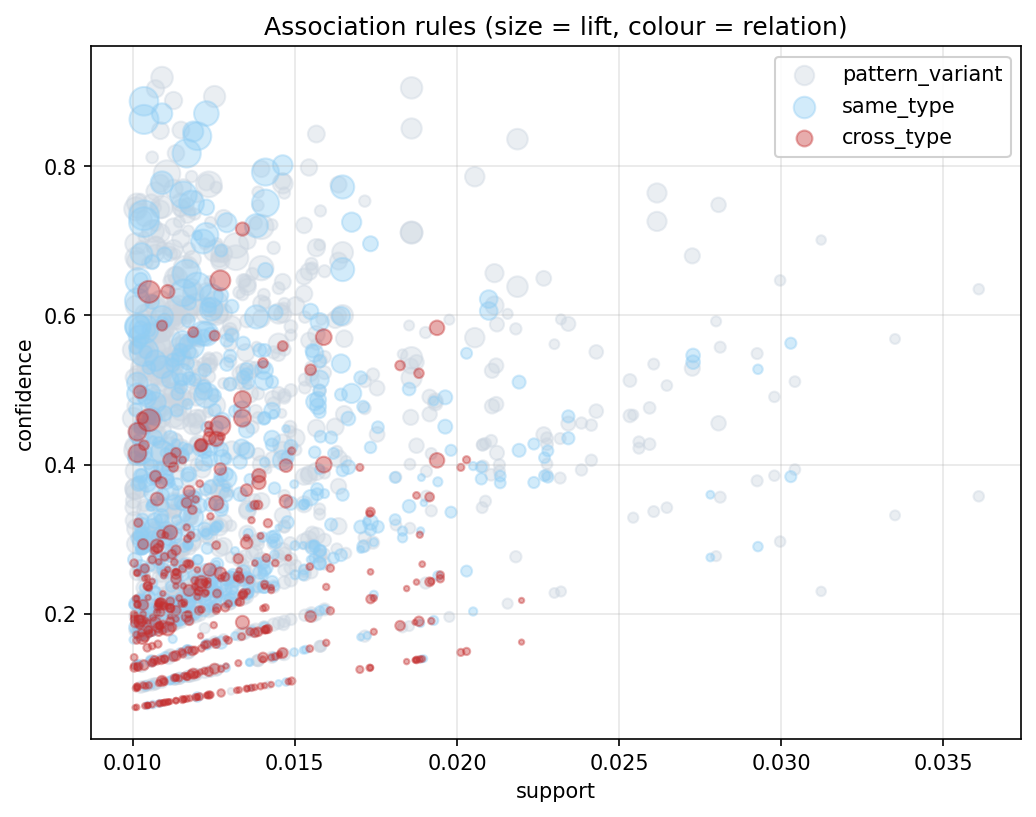

In [6]:
display(Image(filename="results/basket/figures/rules_scatter.png"))

### Three co-purchase patterns

Reading the cross-type rules, three behaviours stand out:

1. **Completing a coordinated range.** The Red Retrospot tableware — cup, plate, bowl, jug — bought together (lift up to ~28). People building a place setting.
2. **Occasion bundles.** Vintage Christmas cake cases, napkins, and paper chains; the two vintage card games. Someone kitting out for an event in one go.
3. **Pattern collecting.** The same product across colours (the separate `pattern_variant` table). Real, but the obvious one.

In [7]:
display(pd.read_csv("results/basket/tables/top_rules_cross_type.csv"))

,antecedent_names,consequent_names,support,confidence,lift
0,RED RETROSPOT CUP,RED RETROSPOT PLATE,0.010503,0.459579,27.640505
1,RED RETROSPOT PLATE,RED RETROSPOT CUP,0.010503,0.631659,27.640505
2,RED RETROSPOT SMALL MILK JUG,RED RETROSPOT SUGAR JAM BOWL,0.012704,0.451845,23.008003
3,RED RETROSPOT SUGAR JAM BOWL,RED RETROSPOT SMALL MILK JUG,0.012704,0.646907,23.008003
4,RED RETROSPOT BOWL,RED RETROSPOT CUP,0.010148,0.415114,18.164795
5,RED RETROSPOT CUP,RED RETROSPOT BOWL,0.010148,0.444075,18.164795
6,SET OF 20 VINTAGE CHRISTMAS NAPKINS,60 CAKE CASES VINTAGE CHRISTMAS,0.013388,0.487109,16.824835
7,60 CAKE CASES VINTAGE CHRISTMAS,SET OF 20 VINTAGE CHRISTMAS NAPKINS,0.013388,0.462413,16.824835
8,RECYCLING BAG RETROSPOT,TOY TIDY PINK POLKADOT,0.015893,0.400000,14.368727
9,TOY TIDY PINK POLKADOT,RECYCLING BAG RETROSPOT,0.015893,0.570909,14.368727


In [8]:
display(pd.read_csv("results/basket/tables/top_rules_pattern_variant.csv"))

,antecedent_names,consequent_names,support,confidence,lift
0,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN TREE CHRISTMAS SCANDINAVIAN,0.011059,0.569010,40.658007
1,WOODEN TREE CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.011059,0.790235,40.658007
2,SET/10 PINK POLKADOT PARTY CANDLES,SET/10 BLUE SPOTTY PARTY CANDLES,0.012350,0.604709,37.988018
3,SET/10 BLUE SPOTTY PARTY CANDLES,SET/10 PINK POLKADOT PARTY CANDLES,0.012350,0.775835,37.988018
4,BLUE POLKADOT CUP,PINK POLKADOT CUP,0.013185,0.677503,35.646955
5,PINK POLKADOT CUP,BLUE POLKADOT CUP,0.013185,0.693742,35.646955
6,BLUE POLKADOT BOWL,PINK POLKADOT BOWL,0.011641,0.663781,34.511354
7,PINK POLKADOT BOWL,BLUE POLKADOT BOWL,0.011641,0.605263,34.511354
8,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.013970,0.718750,34.135442
9,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.013970,0.663462,34.135442


### Limitations

- Association rules show **co-occurrence, not cause**: both items may be driven by a season or a promotion.
- The rule list shifts with the support floor, which was set at 1% and could be tuned.
- The within-line matches dominate unless you read past them, which is why the rules are categorised.

**Result:** three nameable co-purchase patterns, tied back to the seasonality from the EDA and the two wholesale types from segmentation. That completes the project.